# An IDAES flowsheet under drto

Every other example here declares its model by hand. This one takes a unit
model straight out of [IDAES](https://idaes-pse.readthedocs.io/) and drives it
with drto, to show that the declaration surface attaches to a flowsheet
somebody else built.

The plant is a CSTR running the saponification of ethyl acetate,
`NaOH + EthylAcetate -> SodiumAcetate + Ethanol`, from
`idaes.models.unit_models`. The reaction is exothermic, the manipulated
variables are the jacket duty and the feed flow, as in the hicks example, and
the controlled variable is reactor temperature. The reactor starts hot, at
318 K, and short of conversion, and the controller has to bring it to the
304.04 K steady state the nominal feed alone would settle at.

The whole example is two solves on one declared flowsheet: the model collapsed
to its setpoint, and the infinite-horizon controller.

Residence time is `V/F = 1 s` at the nominal flow, so the horizon is ten
seconds at one-second samples: ten residence times on the horizon, with the
infinite tail carrying the rest.

In [1]:
%matplotlib inline
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import drto
from drto import plot_controls, plot_stage_cost, plot_states
from idaes.core.util.model_statistics import degrees_of_freedom
from models.idaes_cstr import DC_START, F_IN, VOLUME, build


## Declaring the flowsheet

`drto.horizon` captures the set's points as the sample grid, so it has to be
called before discretization. That means the sample times go into
`FlowsheetBlock(time_set=...)` up front rather than being introduced by the
discretizer.

The rest maps one-to-one onto what IDAES already built. The states are the
holdups, whose `DerivativeVar`s are the accumulation terms; the dynamics are
the material and enthalpy balances; the controls are the jacket duty and the
feed flow. The duty is declared on `control_volume.heat` and not on the
unit-level `heat_duty`, which is a Pyomo `Reference` to it: drto classifies
on the referent, and declaring the Reference leaves `heat` looking like an
unexplained algebraic variable. The flow has no flat Var at all, its
variables living inside the property-block members, so it is declared on the
inlet Port's time-indexed Reference, the IDAES inlet idiom. After the
transforms, `drto.info(m).components("control")` hands back the live control
components either way.

The targets are mutable Params, declared empty and filled from the steady
solve below: the declarations come first, and the numbers flow in afterward.

The starting point takes no solve, and it pins the true states only. The
reactor is constant volume with constant molar density, so the water holdup
is algebraic (the package fixes its concentration) and carries no initial
condition: the initial condition covers the four reacting species and the
energy. The reactor starts hot and short of conversion: the setpoint
composition knocked back along the reaction by `DC_START`, at 318 K, and
the controller has to bring both back.

In [2]:
declared = build()
drto.info(declared)

<drto registry>
states: 5, controls: 12
declarations:
  horizon: fs._time (ContinuousSet, 11 points)
  states: fs.cstr.control_volume.material_holdup_Liq_NaOH (free, mol), fs.cstr.control_volume.material_holdup_Liq_EthylAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_Ethanol (free, mol), fs.cstr.control_volume.energy_holdup (free, J)
  dynamics: fs.cstr.control_volume.material_accumulation[t,p,j]  ==  fs.cstr.control_volume.properties_in[t].flow_vol*fs.cstr.control_volume.properties_in[t].conc_mol_comp[j] - fs.cstr.control_volume.properties_out[t].flow_vol*fs.cstr.control_volume.properties_out[t].conc_mol_comp[j] + fs.cstr.control_volume.rate_reaction_generation[t,p,j]  for t in fs.cstr.control_volume.SetProduct_OrderedSet  (mol/s)
  dynamics: fs.cstr.control_volume.energy_accumulation[t,Liq]  ==  fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_in[t].flow_vol*(fs.cstr.control_volume.properties_in[t].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[t].flow_vol*(fs.cstr.control_volume.properties_out[t].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat[t] + (- fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[t,R1])  for t in fs._time  (W)
  controls: fs.cstr.control_volume.heat (piecewise_constant, free, W), fs.cstr._flow_vol_inlet_ref (piecewise_constant, free, m**3/s)
  tracking stage cost: cost[t]  ==  ((fs.cstr.control_volume.energy_holdup[t,'Liq'] - eng_ss[Liq])/scale_E)**2 + ((fs.cstr.control_volume.heat[t] - duty_ss)/scale_Q)**2 + ((fs.cstr._flow_vol_inlet_ref[t] - flow_ss)/scale_F)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','NaOH'] - ss_naoh)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','EthylAcetate'] - ss_ea)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','SodiumAcetate'] - ss_sa)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','Ethanol'] - ss_etoh)/scale_M)**2  for t in sorted(fs._time)[:-1]
  terminal cost: term  ==  ((fs.cstr.control_volume.material_holdup[10.0,Liq,NaOH] - ss_naoh)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,EthylAcetate] - ss_ea)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,SodiumAcetate] - ss_sa)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,Ethanol] - ss_etoh)/scale_M)**2 + ((fs.cstr.control_volume.energy_holdup[10.0,Liq] - eng_ss[Liq])/scale_E)**2
  initial conditions: mat0[j]  ==  fs.cstr.control_volume.material_holdup[0.0,'Liq',j]  for j in OrderedScalarSet  (mol)
  initial conditions: eng0[p]  ==  fs.cstr.control_volume.energy_holdup[0.0,p]  for p in fs.props.phase_list  (J)
  steady-state targets: ss_naoh (of fs.cstr.control_volume.material_holdup_Liq_NaOH, mol), ss_ea (of fs.cstr.control_volume.material_holdup_Liq_EthylAcetate, mol), ss_sa (of fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate, mol), ss_etoh (of fs.cstr.control_volume.material_holdup_Liq_Ethanol, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)
  steady-state control targets: duty_ss (of fs.cstr.control_volume.heat, W), flow_ss (of fs.cstr._flow_vol_inlet_ref, m**3/s)
transformations: (none)

## Scaling

The flowsheet runs in raw SI: energy holdups at `1e7` J and duties at `1e6` W
against unit flows, and the collocation equations carry those magnitudes with
order-one coefficients, so double precision floors the residuals near `1e-7`
and the solver stops at an acceptable level instead of full tolerance.
`drto.scale` measures a factor per variable group from the magnitudes the
model holds, and a factor per large constraint from its Jacobian at those
values, so it runs after an initializer has filled the model.
`drto.scaled_solve` assigns the factors and solves: the suffix reaches
pounce under `nlp_scaling_method=user-scaling`, and the solution comes back
in the model's own units. Both solves below run through it, each after its
initializer.

## The setpoint from the declarations

The setpoint is where the nominal feed alone drives the reactor, and the
declared model already contains that equilibrium. `drto.steady_state_simulation`
collapses the flowsheet to a single point and fixes the controls, the duty at
zero and the flow at its nominal value: time leaves the model, the
accumulation terms are pinned, and the IDAES property blocks collapse to
their steady member alongside the flat holdups. The steady
target comes from the same physics the controller uses, with no second
flowsheet to build or keep in sync.

The solution fills the mutable Params: the tracking targets, and the base
composition the initial condition perturbs. The controller below is built by
its own call, so the numbers are collected here and written onto it there.

In [3]:
ss = pyo.TransformationFactory("drto.steady_state_simulation").create_using(
    declared, controls={declared.fs.cstr.control_volume.heat.name: 0.0,
                        declared.fs.cstr.inlet.flow_vol.name: F_IN})
assert degrees_of_freedom(ss) == 0
print(drto.initialize_steady_state(ss))
res = drto.scaled_solve(ss, tee=True)

cvs = ss.fs.cstr.control_volume
print(f"setpoint  T = {pyo.value(cvs.properties_out[0.0].temperature):7.3f} K"
      f"   NaOH = {pyo.value(cvs.properties_out[0.0].conc_mol_comp['NaOH']):6.3f} mol/m3")

# the controller below is its own build, so the numbers are collected here
# and written onto it rather than onto this model
target = {name: pyo.value(cvs.material_holdup["Liq", j])
          for j, name in (("NaOH", "ss_naoh"), ("EthylAcetate", "ss_ea"),
                          ("SodiumAcetate", "ss_sa"), ("Ethanol", "ss_etoh"))}
# the start: the setpoint composition with conversion knocked back by
# DC_START along the reaction stoichiometry, hot by T_START - T_ss
start = {j: pyo.value(cvs.material_holdup["Liq", j]) + sgn * DC_START * VOLUME
         for j, sgn in (("NaOH", 1), ("EthylAcetate", 1),
                        ("SodiumAcetate", -1), ("Ethanol", -1))}
energy = {k: pyo.value(cvs.energy_holdup[k]) for k in declared.eng_ss}
drto.info(ss)

pyomo-pounce initialize (fill -> repair -> block-solve)
  decisions held: 0
  values filled : 0
  projection    : optimal
  pyomo-pounce block_initialize
    decisions fixed   : 0
    system square     : True
    blocks solved     : 15 (14 by Newton 1x1, 1 subsystem solves)
    vars initialized  : 22
    left untouched    : 0 underdetermined, 0 overdetermined


********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.11.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpnx6m2rp_\unknownm445eb0j.nl...
Parsed

C:\Users\Devin\AppData\Local\Temp\tmpnx6m2rp_\unknownm445eb0j.sol


setpoint  T = 304.039 K   NaOH = 24.286 mol/m3


<drto registry>
states: 5, controls: 2
declarations:
  states: fs.cstr.control_volume.material_holdup_Liq_NaOH (free), fs.cstr.control_volume.material_holdup_Liq_EthylAcetate (free), fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate (free), fs.cstr.control_volume.material_holdup_Liq_Ethanol (free), fs.cstr.control_volume.energy_holdup (free)
  dynamics: fs.cstr.control_volume.material_accumulation[o,_r]  ==  fs.cstr.control_volume.properties_in[0.0].flow_vol*fs.cstr.control_volume.properties_in[0.0].conc_mol_comp[_r] - fs.cstr.control_volume.properties_out[0.0].flow_vol*fs.cstr.control_volume.properties_out[0.0].conc_mol_comp[_r] + fs.cstr.control_volume.rate_reaction_generation[o,_r]  for o in fs.props._phase_component_set  (inc)
  dynamics: fs.cstr.control_volume.energy_accumulation[Liq]  ==  fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_in[0.0].flow_vol*(fs.cstr.control_volume.properties_in[0.0].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[0.0].flow_vol*(fs.cstr.control_volume.properties_out[0.0].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat - fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[R1]  (inc)
  controls: fs.cstr.control_volume.heat (fixed), fs.cstr._flow_vol_inlet_ref (fixed, m**3/s)
  steady-state targets: ss_naoh (of fs.cstr.control_volume.material_holdup_Liq_NaOH, mol), ss_ea (of fs.cstr.control_volume.material_holdup_Liq_EthylAcetate, mol), ss_sa (of fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate, mol), ss_etoh (of fs.cstr.control_volume.material_holdup_Liq_Ethanol, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)
  steady-state control targets: duty_ss (of fs.cstr.control_volume.heat, W), flow_ss (of fs.cstr._flow_vol_inlet_ref, m**3/s)
transformations:
  drto.dynamic_to_steady_state: removed=initial condition, tracking terminal cost, collapsed=8 Vars and 8 Constraints to a single point, derivatives=2 fixed at zero, blocks=3 time-indexed Block(s) collapsed to the steady member, 30 member(s) removed
  drto.build_objective: objective=zero
  drto.steady_state_simulation: controls=fs.cstr.control_volume.heat=0.0, fs.cstr._flow_vol_inlet_ref=1.0, dropped=tracking stage cost

## The infinite-horizon controller

`drto.dynamic_optimization` takes the builder rather than a model and reaches
the controller in one call: it discretizes the horizon at one finite element
per declared sample, applies `drto.infinite_horizon` with the options given,
and assembles the objective. The builder fixes the feed at the declared
sample points, which is all an undiscretized model has, and the call fixes
the members collocation adds to it.

The terminal segment replicates the IDAES property blocks onto the tail as
algebraic families, and the feed conditions carry onto it with no declaration
involved. The concentrations, temperature, and pressure are fixed variables,
and fixed means fixed: each one's segment copy is fixed at its horizon-end
value. (They are not disturbances: drto's disturbances are zero-mean noise,
which the optimization mode fixes at zero on the horizon.)

`drto.cold_start_dynamic` then fills the model, interpolating each state from
its declared initial condition to its target, solving the algebra at every
point, and placing the segment's copies at the targets.

In [4]:
# the horizon discretized, the terminal segment appended, and the objective
# assembled, from the builder in one call
m = drto.dynamic_optimization(
    build, N=10,
    infinite_horizon={
        "nfe": 1,                  # finite elements on the terminal segment
        "ncp": 5,                  # Gauss-Legendre points per element
        "beta": 1.2,               # tail overestimation factor, > 1
        "gamma": "rule",           # the mesh rule, tanh(gamma*dt) = tau_11;
                                   # pass a number to override
        "profile": "collocation",  # segment control profile (pyomo-cvp)
    },
)
for name, value in target.items():
    m.component(name).set_value(value)
for j, value in start.items():
    m.mat0[j] = value
for k, value in energy.items():
    m.eng_ss[k] = value

print(drto.cold_start_dynamic(m, scale={"J": 1e7, "W": 1e6}))
print("degrees of freedom:", degrees_of_freedom(m))

component keys that are not exported as part of the NL file.  Skipping.


drto cold_start_dynamic (interpolate to the targets)
  states        : 5 on a line across 31 grid points
  derivatives   : 155 at the profile's slope
  controls      : 2 at their targets
  segment       : 12 copies at the targets, slacks at zero
  point solves  : run (pyomo-pounce block solve)
  pyomo-pounce initialize (fill -> repair -> block-solve)
    decisions held: 220
    values filled : 0
    projection    : skipped
    pyomo-pounce block_initialize
      decisions fixed   : 0
      system square     : True
      blocks solved     : 822 (822 by Newton 1x1, 0 subsystem solves)
      vars initialized  : 822
      left untouched    : 0 underdetermined, 0 overdetermined
degrees of freedom: 41


In [5]:
res = drto.scaled_solve(m, tee=True)
drto.info(m)

component keys that are not exported as part of the NL file.  Skipping.


component keys that are not exported as part of the NL file.  Skipping.


********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) — drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.11.0, running with linear solver FERAL.



Number of nonzeros in equality constraint Jacobian...:     3442
Number of nonzeros in inequality constraint Jacobian.:       10
Number of nonzeros in Lagrangian Hessian.............:      475

Total number of variables............................:     1099
                     variables with only lower bounds:      272
                variables with lower and upper bounds:       72
                     variables with only upper bounds:        0
Total number of equality constraints.................:     1058
Total number of inequality constraints...............:        2
        inequality constraints with only lower bounds:        2
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  1.3163721e+04 3.01e+07 1.00e+04   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0
   1 -6.9806537e+03 5.64e+07 9.96e+03   -1.0 5.74e+15      - 2.9

   7 -4.8567994e+04 4.37e+07 1.04e+04   -1.0 6.00e+13      - 4.12e-01 2.75e-01f  1
   8 -1.6367169e+04 1.60e+07 1.28e+04   -1.0 4.87e+13      - 5.78e-01 6.96e-01h  1
   9  2.0151087e+03 2.33e+07 1.64e+03   -1.0 4.21e+13      - 7.79e-01 1.00e+00h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  10  3.3323996e+03 4.38e+06 1.22e+03   -1.0 1.29e+14      - 9.90e-01 1.00e+00h  1
  11  3.5141282e+03 2.20e+05 3.01e+02   -1.0 1.30e+16      - 8.22e-01 1.00e+00h  1
  12  3.5384512e+03 2.61e+03 1.10e+00   -1.0 7.19e+16      - 1.00e+00 1.00e+00h  1
  13  3.5386477e+03 4.25e-01 9.76e-05   -1.0 5.45e+18      - 1.00e+00 1.00e+00f  1
  14  3.5376450e+03 2.78e+01 8.37e-02   -2.5 4.78e+10      - 1.00e+00 1.00e+00f  1
  15  3.5376596e+03 9.77e-04 1.38e-06   -2.5 5.42e+07      - 1.00e+00 1.00e+00h  1
  16  3.5376328e+03 2.13e-02 6.46e-05   -3.8 1.31e+09      - 1.00e+00 1.00e+00f  1
  17  3.5376313e+03 5.86e-03 2.00e-07   -5.7 2.14e+07      - 1.00e+00 1.00e+00f  1


  18  3.5376313e+03 2.93e-03 9.33e-02   -8.6 1.01e+08      - 1.00e+00 9.91e-01h  1
  19  3.5376313e+03 4.76e-04 5.44e-09   -8.6 4.63e+06      - 1.00e+00 1.00e+00f  1




Number of Iterations....: 19

                                   (scaled)                 (unscaled)
Objective...............:   3.5376313199988058e+03    3.5376313199988058e+03
Dual infeasibility......:   5.4431997319876776e-09    5.4431997319876776e-09
Constraint violation....:   2.5354290989045535e-09    4.7645073465218962e-04
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   3.7457153056570389e-09    3.7457153056570389e-09
Overall NLP error.......:   4.4836254900541825e-09    4.7645073465218962e-04


Number of objective function evaluations             = 21
Number of objective gradient evaluations             = 20
Number of equality constraint evaluations            = 21
Number of inequality constraint evaluations          = 21
Number of equality constraint Jacobian evaluations   = 20
Number of inequality constraint Jacobian evaluations = 20
Number of Lagrangian Hessian evaluations             = 20
Number of linear solver qua

<drto registry>
states: 5, controls: 2
declarations:
  horizon: fs._time (ContinuousSet, 31 points)
  states: fs.cstr.control_volume.material_holdup_Liq_NaOH (free, mol), fs.cstr.control_volume.material_holdup_Liq_EthylAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_Ethanol (free, mol), fs.cstr.control_volume.energy_holdup (free, J)
  dynamics: fs.cstr.control_volume.material_accumulation[t,p,j]  ==  fs.cstr._flow_vol_inlet_ref[0.0]*fs.cstr.control_volume.properties_in[t].conc_mol_comp[j] - fs.cstr.control_volume.properties_out[t].flow_vol*fs.cstr.control_volume.properties_out[t].conc_mol_comp[j] + fs.cstr.control_volume.rate_reaction_generation[t,p,j]  for t in fs.cstr.control_volume.SetProduct_OrderedSet  (mol/s)
  dynamics: fs.cstr.control_volume.energy_accumulation[t,Liq]  ==  fs.props.dens_mol*fs.props.cp_mol*fs.cstr._flow_vol_inlet_ref[0.0]*(fs.cstr.control_volume.properties_in[t].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[t].flow_vol*(fs.cstr.control_volume.properties_out[t].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat[0.0] - fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[t,R1]  for t in fs._time  (W)
  controls: fs.cstr.control_volume.heat (piecewise_constant, free, W), fs.cstr._flow_vol_inlet_ref (piecewise_constant, free, m**3/s)
  tracking stage cost: cost[t]  ==  ((fs.cstr.control_volume.energy_holdup[t,'Liq'] - eng_ss[Liq])/scale_E)**2 + ((fs.cstr.control_volume.heat[t] - duty_ss)/scale_Q)**2 + ((_flow_vol_inlet_ref[t] - flow_ss)/scale_F)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','NaOH'] - ss_naoh)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','EthylAcetate'] - ss_ea)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','SodiumAcetate'] - ss_sa)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','Ethanol'] - ss_etoh)/scale_M)**2  for t in sorted(fs._time)[:-1]
  terminal cost: term  ==  ((fs.cstr.control_volume.material_holdup[10.0,Liq,NaOH] - ss_naoh)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,EthylAcetate] - ss_ea)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,SodiumAcetate] - ss_sa)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,Ethanol] - ss_etoh)/scale_M)**2 + ((fs.cstr.control_volume.energy_holdup[10.0,Liq] - eng_ss[Liq])/scale_E)**2
  initial conditions: mat0[j]  ==  fs.cstr.control_volume.material_holdup[0.0,'Liq',j]  for j in OrderedScalarSet  (mol)
  initial conditions: eng0[p]  ==  fs.cstr.control_volume.energy_holdup[0.0,p]  for p in fs.props.phase_list  (J)
  steady-state targets: ss_naoh (of fs.cstr.control_volume.material_holdup_Liq_NaOH, mol), ss_ea (of fs.cstr.control_volume.material_holdup_Liq_EthylAcetate, mol), ss_sa (of fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate, mol), ss_etoh (of fs.cstr.control_volume.material_holdup_Liq_Ethanol, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)
  steady-state control targets: duty_ss (of fs.cstr.control_volume.heat, W), flow_ss (of fs.cstr._flow_vol_inlet_ref, m**3/s)
transformations:
  drto.infinite_horizon: segment=1 elements x 5 Legendre points, beta=1.2, gamma=0.04694445, profile=collocation, horizon=kept, infinite tail appended, algebraic=3 components replicated, blocks=3 time-indexed Block(s): 9 components, 3 equation families replicated, partial=algebraic entries of 2 indexed Var(s) copied per member, terminal_cost=terminal deactivated (the tail owns it), terminal=soft pin z(tau=1)=z_s on 5 states, mu=1000.0
  drto.parameterize: profiles=fs.cstr.control_volume.heat (piecewise_constant), fs.cstr._flow_vol_inlet_ref (piecewise_constant)
  drto.build_objective: objective=sum of 35 weighted cost terms
  drto.dynamic_optimization: horizon=kept, tracking_weight=(one stage cost declared), sensitivity=5 initial-condition Params declared

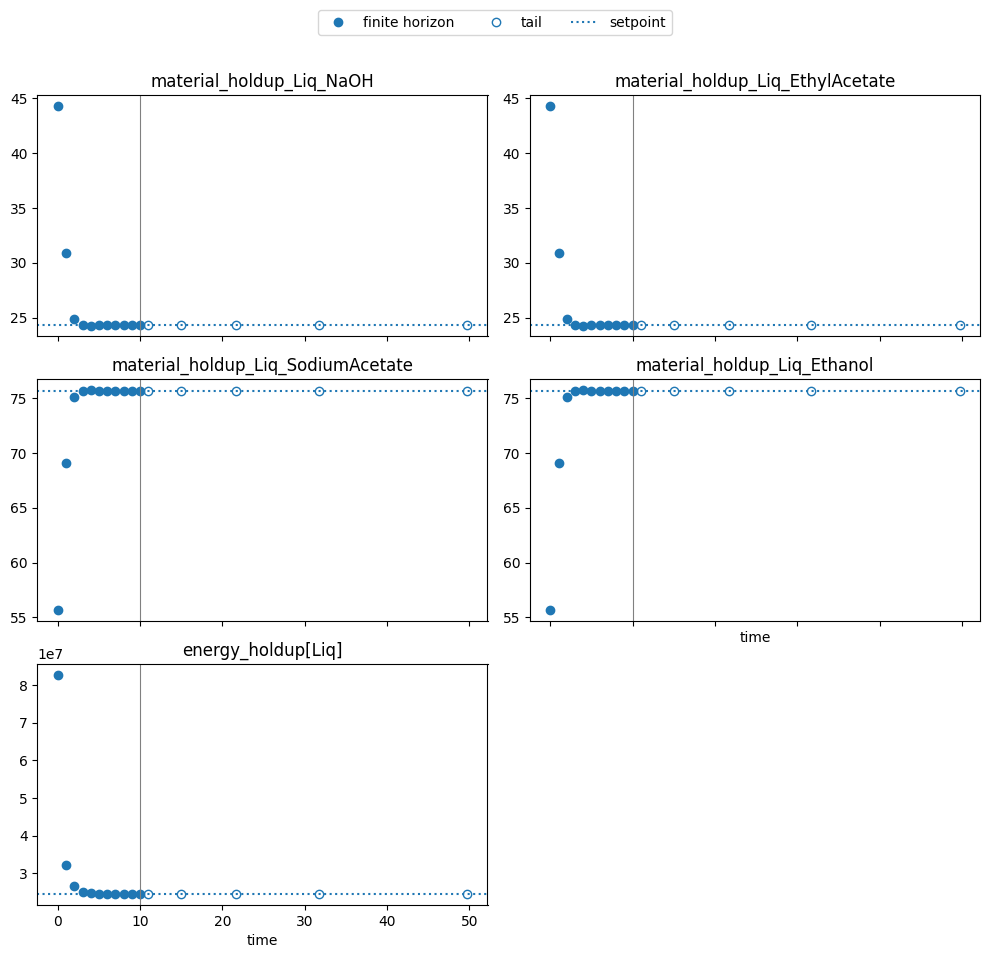

In [6]:
# drto-aware plotting: filled points on the finite horizon, open points on
# the terminal segment mapped back to real time, dotted setpoint lines from
# the declared pairings. With V = 1 m3 the material holdup reads as
# concentration, and the energy holdup is the temperature story in J.
plot_states(m);
plt.show()

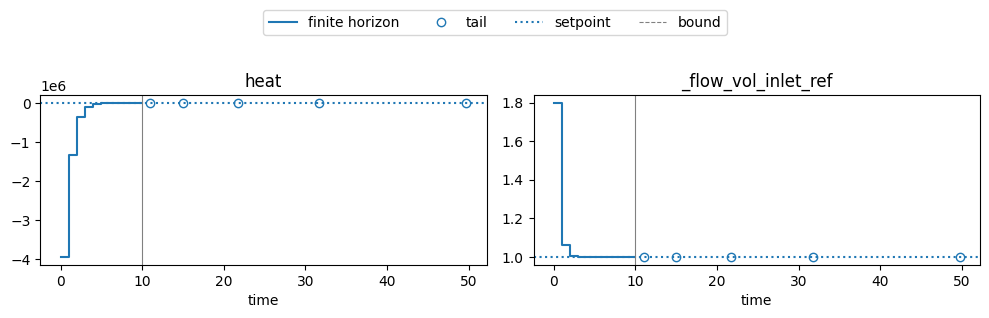

In [7]:
plot_controls(m);
plt.show()

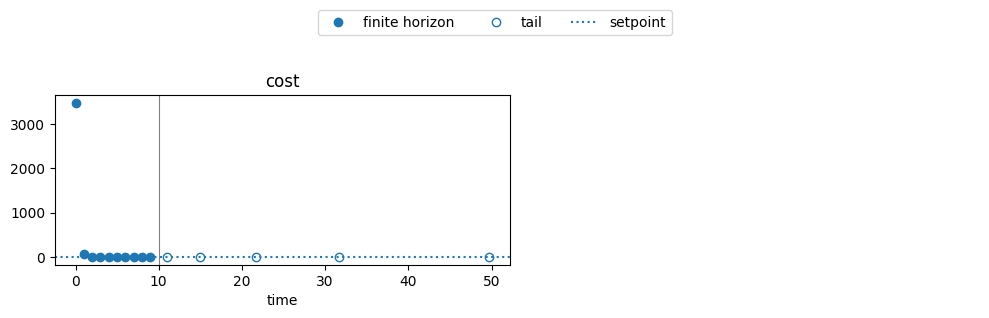

In [8]:
plot_stage_cost(m);
plt.show()